#   HW1 - Introduction to Image Processing Course



### 1. Environment Setup and Preparations

**Import libraries**

In [85]:
import sys
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.image import imread, imsave
import pandas as pd
import numpy as np
import tensorflow as tf
import skimage as ski
from skimage.io import imread
from skimage import img_as_float
from PIL import Image

**Libraries versions**

In [86]:
print('pandas version: '+ pd.__version__)
print('numpy version: '+np.__version__)
print('tensorflow version: '+tf.__version__)
print('scikit-image version: '+ski.__version__)

pandas version: 2.2.2
numpy version: 1.26.4
tensorflow version: 2.17.0
scikit-image version: 0.24.0


In [87]:
conda_env = os.environ.get('CONDA_DEFAULT_ENV')
print(f"current Conda environment: '{conda_env}'.")

current Conda environment: 'image_processing_env'.


`image_common_utils` functions

In [88]:
# Description: It displays many images in one row
def imshow_all(*images, titles=None):
    images = [img_as_float(img) for img in images]

    if titles is None:
        titles = [''] * len(images)
    vmin = min(map(np.min, images))
    vmax = max(map(np.max, images))
    ncols = len(images)
    height = 5
    width = height * len(images)
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(width, height))
    for ax, img, label in zip(axes.ravel(), images, titles):
        ax.imshow(img, vmin=vmin, vmax=vmax)
        ax.set_title(label)

    return
    # end of imshow_all

# Description: It displays many images in many rows and column
# cmap='gray'; row_plot = 1; img= [img, camera]
def show_image(img, cmap='gray', row_plot = 1):
    if not isinstance(img, list):
        img = [img]

    if len(img) == 1:
        plt.imshow(img[0], cmap=cmap) # cm.gray
    else:
        # Get column count
        col_plot = len(img) // row_plot
        fig, axes = plt.subplots(row_plot, col_plot)
        for count in range(len(img)): # count= 1
            axes[count].imshow(img[count], cmap=cmap)
    plt.show()
    return
# end of show_image


`import_image` function to import all relevant images

In [89]:
def import_image (path):
    img = imread(path)
    img.shape  # H x W x C
    img.size  # multiplication of HxWxC
    type(img)
    img.dtype
    return(img)

Import all images from `image_data` folder

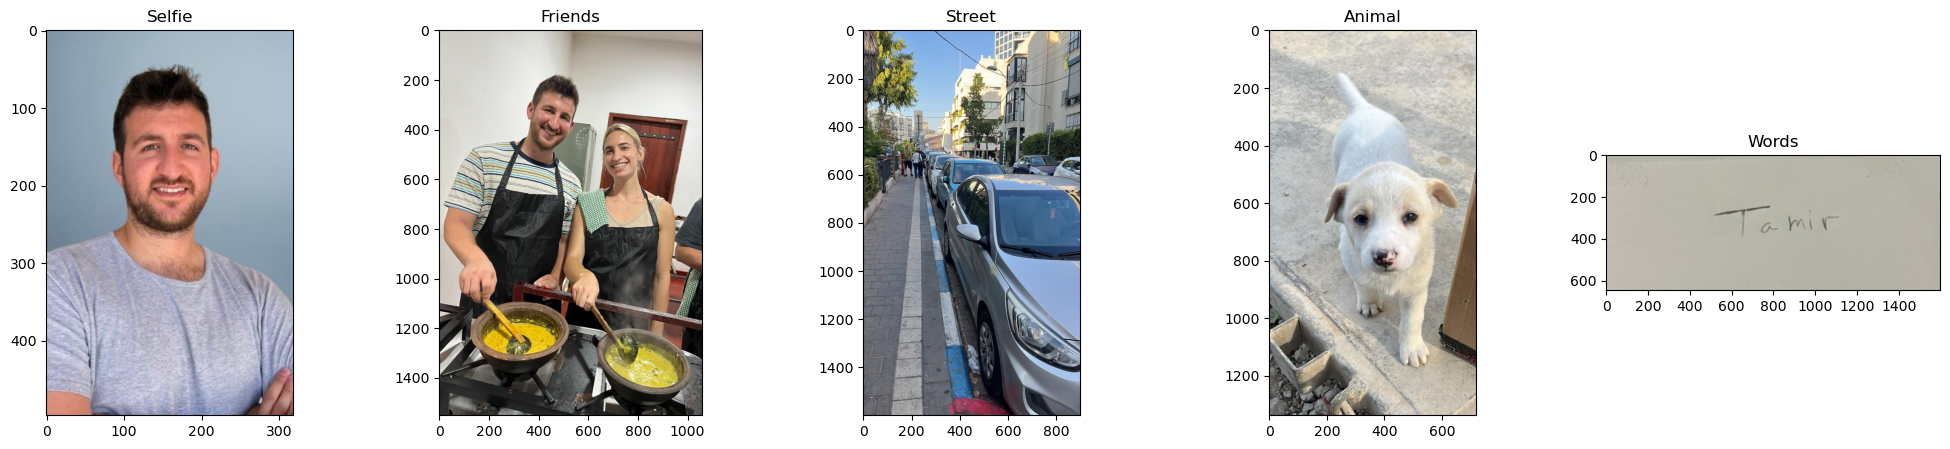

In [93]:
selfie = import_image('./images_data/selfie.jpg')
friends = import_image('./images_data/friends.jpg')
street = import_image('./images_data/street.jpg')
animal = import_image('./images_data/animal.jpg')
words = import_image('./images_data/words.jpg')

imshow_all(selfie, friends, street, animal, words, titles=["Selfie", "Friends", "Street", "Animal", "Words"])

### 2. Image Formats and Color Schemes

Import the wanted image

In [94]:
selfie = import_image('./images_data/selfie.jpg')

Loop function to iterate all the different color schemes and file formats

In [95]:
def change_color_scheme(image, base_name):
    # Define the color schemes and file formats
    color_schemes = {
        "RGB": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        "GRAYSCALE": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
        "HSL": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2HLS),
        "CYMK": lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  # PIL handles CMYK later
    }
    file_formats = [".tiff", ".jpeg", ".png", ".gif"]

    for scheme_name, conversion in color_schemes.items():
        try:
            # Convert the image
            converted_image = conversion(image)

            # Special handling for CMYK
            cmyk_image = None
            if scheme_name == "CYMK":
                converted_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                cmyk_image = converted_image.convert("CMYK")

            for file_format in file_formats:
                try:
                    output_image_name = f"{base_name}_{scheme_name}{file_format}"

                    if scheme_name == "CYMK" and cmyk_image:
                        if file_format == ".gif":
                            cmyk_image.convert("RGB").save(output_image_name, format="GIF")
                        else:
                            cmyk_image.save(output_image_name)
                    else:
                        if len(converted_image.shape) == 2 and file_format != ".gif":  # Grayscale image
                            converted_image_to_save = cv2.cvtColor(converted_image, cv2.COLOR_GRAY2BGR)
                        else:
                            converted_image_to_save = converted_image

                        if file_format == ".gif":
                            Image.fromarray(cv2.cvtColor(converted_image_to_save, cv2.COLOR_BGR2RGB)).save(output_image_name, format="GIF")
                        else:
                            cv2.imwrite(output_image_name, converted_image_to_save)

                    print(f"Saved: {output_image_name}")
                except Exception as e:
                    print(f"Could not save {scheme_name} in {file_format}: {e}")
        except Exception as e:
            print(f"Could not convert to {scheme_name}: {e}")
    return


**Color shcemes**

In [96]:
change_color_scheme(selfie,"selfie")

Saved: selfie_RGB.tiff
Saved: selfie_RGB.jpeg
Saved: selfie_RGB.png
Saved: selfie_RGB.gif
Saved: selfie_GRAYSCALE.tiff
Saved: selfie_GRAYSCALE.jpeg
Saved: selfie_GRAYSCALE.png
Saved: selfie_GRAYSCALE.gif
Saved: selfie_HSL.tiff
Saved: selfie_HSL.jpeg
Saved: selfie_HSL.png
Saved: selfie_HSL.gif
Saved: selfie_CYMK.tiff
Saved: selfie_CYMK.jpeg
Could not save CYMK in .png: cannot write mode CMYK as PNG
Saved: selfie_CYMK.gif


**HEX file format**

In [97]:
def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

def image_to_hex_csv(image, csv_filename):

    # Convert image to a 2D array of HEX colors
    hex_matrix = np.array([[rgb_to_hex(tuple(pixel)) for pixel in row] for row in image])

    # Flatten and create a DataFrame of HEX colors
    hex_colors = hex_matrix.reshape(-1)
    hex_df = pd.DataFrame(hex_colors, columns=['Hex Color'])

    # Save to CSV
    hex_df.to_csv(csv_filename, index=False)
    print(f"Hex color codes saved to {csv_filename}")

    return hex_matrix

**CSV file**

In [98]:
# Save to CSV and get HEX matrix
hex_matrix = image_to_hex_csv(selfie, 'selfie_hex_colors.csv')

# Print a part of the HEX matrix
print(hex_matrix)

Hex color codes saved to selfie_hex_colors.csv
[['#7c91a2' '#7c91a2' '#7c91a2' ... '#a7bac8' '#a8bbc9' '#a9bcca']
 ['#7c91a2' '#7c91a2' '#7d92a3' ... '#a6b9c7' '#a7bac8' '#a8bbc9']
 ['#7c91a2' '#7d92a3' '#7d92a3' ... '#a6b9c7' '#a6b9c7' '#a6b9c7']
 ...
 ['#da8f78' '#da8f78' '#da8f78' ... '#804b3b' '#7e4937' '#804837']
 ['#dc9079' '#db9079' '#dc9079' ... '#7b4636' '#7a4533' '#7d4836']
 ['#dd8f79' '#db8f78' '#dc8e78' ... '#814c3c' '#834e3e' '#855040']]


### 3. Upscaling and Downscaling

**Upscaling & Downscaling functions**

In [101]:
def upscale_image(image, base_name):
   
    # Get original dimensions
    original_height, original_width = image.shape[:2]

    # Calculate new dimensions
    new_height = original_height * 2
    new_width = original_width * 2

    # Upscale the image
    upscaled_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

    # Print new dimensions
    print(f"New upscaled dimensions: {new_width}x{new_height}")

    # Save the upscaled image
    save_path = f"{base_name}_upscale.jpeg"
    cv2.imwrite(save_path, cv2.cvtColor(upscaled_image, cv2.COLOR_RGB2BGR))

    return(upscale_image)


def downscale_image(image, base_name):
   
    # Get original dimensions
    original_height, original_width = image.shape[:2]

    # Calculate new dimensions
    new_height = int(original_height * 0.5)
    new_width = int(original_width * 0.5)

    # Upscale the image
    downscaled_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

    # Print new dimensions
    print(f"New downscaled dimensions: {new_width}x{new_height}")

    # Save the upscaled image
    save_path = f"{base_name}_downscale.jpeg"
    cv2.imwrite(save_path, cv2.cvtColor(downscaled_image, cv2.COLOR_RGB2BGR))

    return(downscale_image)


In [102]:
print(f"Old dimensions: {selfie.shape[1]}x{selfie.shape[0]}")
upscale_selfie = upscale_image(selfie, "selfie")
downscale_selfie = downscale_image(selfie, "selfie") 

Old dimensions: 319x497
New upscaled dimensions: 638x994
New downscaled dimensions: 159x248


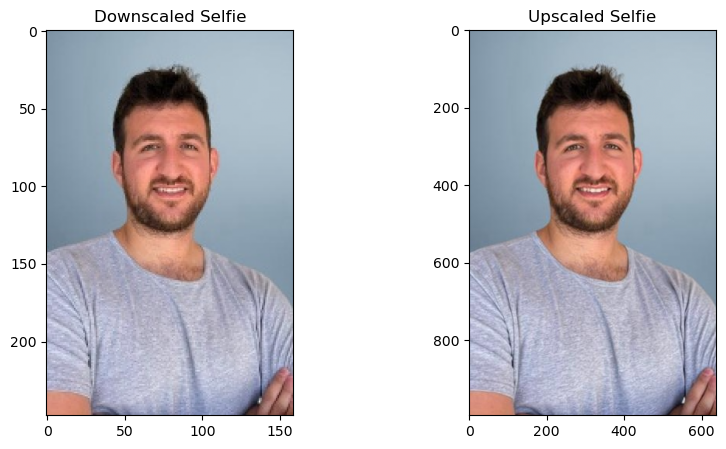

In [108]:
downscaled_selfie = import_image('selfie_downscale.jpeg')
upscaled_selfie = import_image('selfie_upscale.jpeg')

imshow_all(downscaled_selfie, upscaled_selfie, titles=["Downscaled Selfie", "Upscaled Selfie"])

### 4. Shape Drawing

### 5. Video Annotation

### 6. Image Histogram Analysis